# Rooftop Feature Classification with ResNet18

This notebook trains and evaluates the **multi-label rooftop-feature classifier** used by the Vienna Roof Explorer application.

A single roof image may contain several features at the same time, so the task is formulated as **multi-label classification** rather than mutually exclusive multiclass classification. The target classes are:

- `chimney`
- `roof-vegetation`
- `rooftop-hvac`
- `skylight`
- `solar`

The workflow covers dataset validation, class-imbalance analysis, multilabel-stratified splitting, augmentation, transfer learning with ResNet18, staged fine-tuning, and cross-validation.

> **Reproducibility:** all paths are resolved relative to the cloned repository. No machine-specific absolute paths are required.


In [21]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image


def find_project_root(start: Path | None = None) -> Path:
    """
    Locate the vienna_roof_explorer repository root.

    Works when the notebook is launched from anywhere
    inside the cloned repository.
    """
    start = (start or Path.cwd()).resolve()

    for folder in [start, *start.parents]:
        if (
            (folder / "app").is_dir()
            and (folder / "training").is_dir()
            and (folder / "requirements.txt").is_file()
        ):
            return folder

    raise FileNotFoundError(
        "Could not locate the project root. "
        "Run this notebook from inside the vienna_roof_explorer repository."
    )


PROJECT_ROOT = find_project_root()

TRAINING_ROOT = PROJECT_ROOT / "training"
DATA_ROOT = TRAINING_ROOT / "data"

ROOF_ELEMENTS_ROOT = DATA_ROOT / "roof_elements"
IMAGE_DIR = ROOF_ELEMENTS_ROOT / "images"
CSV_PATH = ROOF_ELEMENTS_ROOT / "annotations" / "classes.csv"

print(f"Project root : {PROJECT_ROOT}")
print(f"Training root: {TRAINING_ROOT}")
print(f"Data root    : {DATA_ROOT}")
print(f"Images       : {IMAGE_DIR}")
print(f"Labels       : {CSV_PATH}")

Project root : C:\Users\Marco\Documents\vienna_roof_explorer
Training root: C:\Users\Marco\Documents\vienna_roof_explorer\training
Data root    : C:\Users\Marco\Documents\vienna_roof_explorer\training\data
Images       : C:\Users\Marco\Documents\vienna_roof_explorer\training\data\roof_elements\images
Labels       : C:\Users\Marco\Documents\vienna_roof_explorer\training\data\roof_elements\annotations\classes.csv


## 1. Dataset overview and class distribution

The annotation CSV contains one row per roof image and one binary column per rooftop feature. Because multiple labels can be active for the same image, class prevalence is inspected independently for each feature.

The class counts are also used to derive `pos_weight` values for `BCEWithLogitsLoss`. This reduces the tendency of the model to favor common classes when the dataset is imbalanced.


Dataset shape: (94, 6)

Columns:
['filename', 'chimney', 'roof-vegetation', 'rooftop-hvac', 'skylight', 'solar']

First rows:


,filename,chimney,roof-vegetation,rooftop-hvac,skylight,solar
0,BW_5715648_png.rf.i9Y50YqchM5RZK2cS9f5.png,0,0,1,0,0
1,BW_5735827_png.rf.5r71xudrMxyGXBQSOYB7.png,1,0,0,0,1
2,BW_5750233_png.rf.8vTQlGZ6Xx6ldFj6J15p.png,0,0,1,0,1
3,BW_5629778_png.rf.4EdL4vPv5nrtUVVU0i8v.png,0,0,1,0,0
4,BW_5599232_png.rf.FlxEJL1bdY7MIisP0EPl.png,0,0,1,0,1
5,BW_5739323_png.rf.4zLzGLqHMuq1Uz4dRwjF.png,0,0,0,0,1
6,BW_5545631_png.rf.BsBvPCf8g764c1qSwaWU.png,1,0,0,1,0
7,BW_5551563_png.rf.7CCR0A322xpFA56sJ4Ga.png,1,0,0,0,0
8,BW_5629793_png.rf.HaJyg0wrlnYGOWYnFFlx.png,0,0,1,0,0
9,BW_5725913_png.rf.6z9frk09jFkIc9sETz5q.png,0,0,1,1,1


,positive,negative,positive_%,pos_weight
roof-vegetation,16,78,17.02,4.88
skylight,24,70,25.53,2.92
chimney,34,60,36.17,1.76
solar,39,55,41.49,1.41
rooftop-hvac,41,53,43.62,1.29


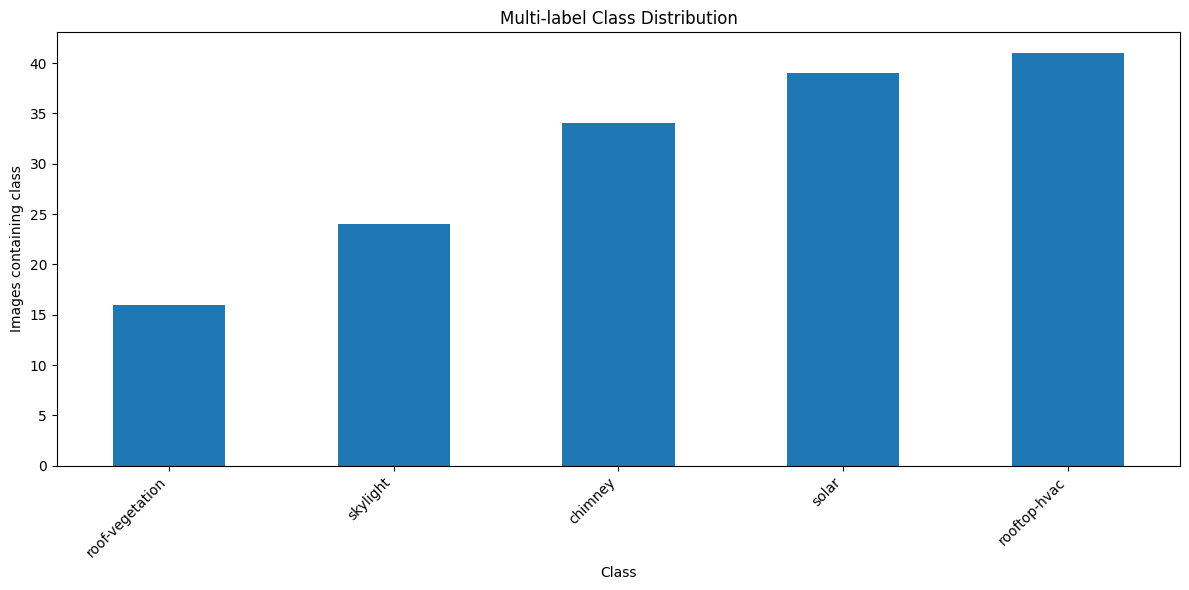

In [22]:
df = pd.read_csv(CSV_PATH)

# Clean column names
df.columns = df.columns.str.strip()

print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst rows:")
display(df.head(10))


# First column contains the image filename
filename_col = df.columns[0]

# Remaining columns are binary multi-label targets
class_cols = df.columns[1:]


# Number of positive examples
positive_counts = df[class_cols].sum()

# Number of negative examples
negative_counts = len(df) - positive_counts

# Percentage of images containing each class
positive_percent = positive_counts / len(df) * 100

# Class weights for BCEWithLogitsLoss
pos_weight = negative_counts / positive_counts


stats = pd.DataFrame({
    "positive": positive_counts,
    "negative": negative_counts,
    "positive_%": positive_percent.round(2),
    "pos_weight": pos_weight.round(2),
})

stats = stats.sort_values("positive")

display(stats)


plt.figure(figsize=(12, 6))
positive_counts.sort_values().plot(kind="bar")

plt.ylabel("Images containing class")
plt.xlabel("Class")
plt.title("Multi-label Class Distribution")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 2. Dataset integrity checks

Before training, the annotations are checked against the image directory. This step verifies that every filename referenced by the CSV exists on disk and constructs the full image path used by the PyTorch dataset.

Keeping this validation explicit makes dataset problems fail early instead of appearing later as training-time file errors.


In [23]:
# Reload labels to keep this validation cell self-contained
df = pd.read_csv(CSV_PATH)
df.columns = df.columns.str.strip()

print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

display(df.head())


# ---------------------------------------------------------------
# Identify filename + label columns
# ---------------------------------------------------------------

filename_col = df.columns[0]

class_cols = [
    col
    for col in df.columns
    if col != filename_col
]

print("\nFilename column:")
print(filename_col)

print("\nClasses:")
for i, class_name in enumerate(class_cols):
    print(f"{i}: {class_name}")


# ---------------------------------------------------------------
# Create complete image paths
# ---------------------------------------------------------------

df["image_path"] = df[filename_col].apply(
    lambda filename: IMAGE_DIR / str(filename).strip()
)


# ---------------------------------------------------------------
# Verify that every image exists
# ---------------------------------------------------------------

df["image_exists"] = df["image_path"].apply(Path.exists)

missing = df.loc[
    ~df["image_exists"],
    [filename_col, "image_path"],
]

print("\nImages in CSV:", len(df))
print("Images found:", df["image_exists"].sum())
print("Images missing:", len(missing))

if len(missing) > 0:
    print("\nMissing images:")
    display(missing)
else:
    print("\nAll CSV images were found.")

Dataset shape: (94, 6)

Columns:
['filename', 'chimney', 'roof-vegetation', 'rooftop-hvac', 'skylight', 'solar']


,filename,chimney,roof-vegetation,rooftop-hvac,skylight,solar
0,BW_5715648_png.rf.i9Y50YqchM5RZK2cS9f5.png,0,0,1,0,0
1,BW_5735827_png.rf.5r71xudrMxyGXBQSOYB7.png,1,0,0,0,1
2,BW_5750233_png.rf.8vTQlGZ6Xx6ldFj6J15p.png,0,0,1,0,1
3,BW_5629778_png.rf.4EdL4vPv5nrtUVVU0i8v.png,0,0,1,0,0
4,BW_5599232_png.rf.FlxEJL1bdY7MIisP0EPl.png,0,0,1,0,1



Filename column:
filename

Classes:
0: chimney
1: roof-vegetation
2: rooftop-hvac
3: skylight
4: solar

Images in CSV: 94
Images found: 94
Images missing: 0

All CSV images were found.


### 2.1 Extra files and label validation

The image directory is also checked for files that are not represented in the annotation CSV. Label columns are converted to numeric values and their unique values are inspected to confirm that the targets are valid binary indicators.


In [24]:
# ---------------------------------------------------------------
# Find image files that are NOT present in the CSV
# ---------------------------------------------------------------

image_extensions = {
    ".png",
    ".jpg",
    ".jpeg",
    ".tif",
    ".tiff",
    ".webp",
}

folder_images = {
    file.name
    for file in IMAGE_DIR.iterdir()
    if file.is_file()
    and file.suffix.lower() in image_extensions
}

csv_images = set(
    df[filename_col]
    .astype(str)
    .str.strip()
)

extra_images = sorted(folder_images - csv_images)

print("\nImage files in folder:", len(folder_images))
print("Images listed in CSV:", len(csv_images))
print("Extra images not listed in CSV:", len(extra_images))

if extra_images:
    display(
        pd.DataFrame({
            "extra_image": extra_images
        })
    )


# ---------------------------------------------------------------
# Make sure labels are numeric
# ---------------------------------------------------------------

df[class_cols] = df[class_cols].apply(
    pd.to_numeric,
    errors="raise",
)

print("\nUnique values per class:")

for class_name in class_cols:
    print(
        f"{class_name}: "
        f"{sorted(df[class_name].unique().tolist())}"
    )


# ---------------------------------------------------------------
# Final dataset preview
# ---------------------------------------------------------------

display(
    df[
        [filename_col, "image_path"]
        + class_cols
    ].head(10)
)


Image files in folder: 94
Images listed in CSV: 94
Extra images not listed in CSV: 0

Unique values per class:
chimney: [0, 1]
roof-vegetation: [0, 1]
rooftop-hvac: [0, 1]
skylight: [0, 1]
solar: [0, 1]


,filename,image_path,chimney,roof-vegetation,rooftop-hvac,skylight,solar
0,BW_5715648_png.rf.i9Y50YqchM5RZK2cS9f5.png,C:\Users\Marco\Documents\vienna_roof_explorer\...,0,0,1,0,0
1,BW_5735827_png.rf.5r71xudrMxyGXBQSOYB7.png,C:\Users\Marco\Documents\vienna_roof_explorer\...,1,0,0,0,1
2,BW_5750233_png.rf.8vTQlGZ6Xx6ldFj6J15p.png,C:\Users\Marco\Documents\vienna_roof_explorer\...,0,0,1,0,1
3,BW_5629778_png.rf.4EdL4vPv5nrtUVVU0i8v.png,C:\Users\Marco\Documents\vienna_roof_explorer\...,0,0,1,0,0
4,BW_5599232_png.rf.FlxEJL1bdY7MIisP0EPl.png,C:\Users\Marco\Documents\vienna_roof_explorer\...,0,0,1,0,1
5,BW_5739323_png.rf.4zLzGLqHMuq1Uz4dRwjF.png,C:\Users\Marco\Documents\vienna_roof_explorer\...,0,0,0,0,1
6,BW_5545631_png.rf.BsBvPCf8g764c1qSwaWU.png,C:\Users\Marco\Documents\vienna_roof_explorer\...,1,0,0,1,0
7,BW_5551563_png.rf.7CCR0A322xpFA56sJ4Ga.png,C:\Users\Marco\Documents\vienna_roof_explorer\...,1,0,0,0,0
8,BW_5629793_png.rf.HaJyg0wrlnYGOWYnFFlx.png,C:\Users\Marco\Documents\vienna_roof_explorer\...,0,0,1,0,0
9,BW_5725913_png.rf.6z9frk09jFkIc9sETz5q.png,C:\Users\Marco\Documents\vienna_roof_explorer\...,0,0,1,1,1


## 3. Visual sanity check

A random sample of labeled roof images is displayed together with its active labels. This is a lightweight but important quality-control step: it helps catch obvious annotation mistakes, mismatched filenames, unexpected image crops, or labels that do not visually correspond to the roof.


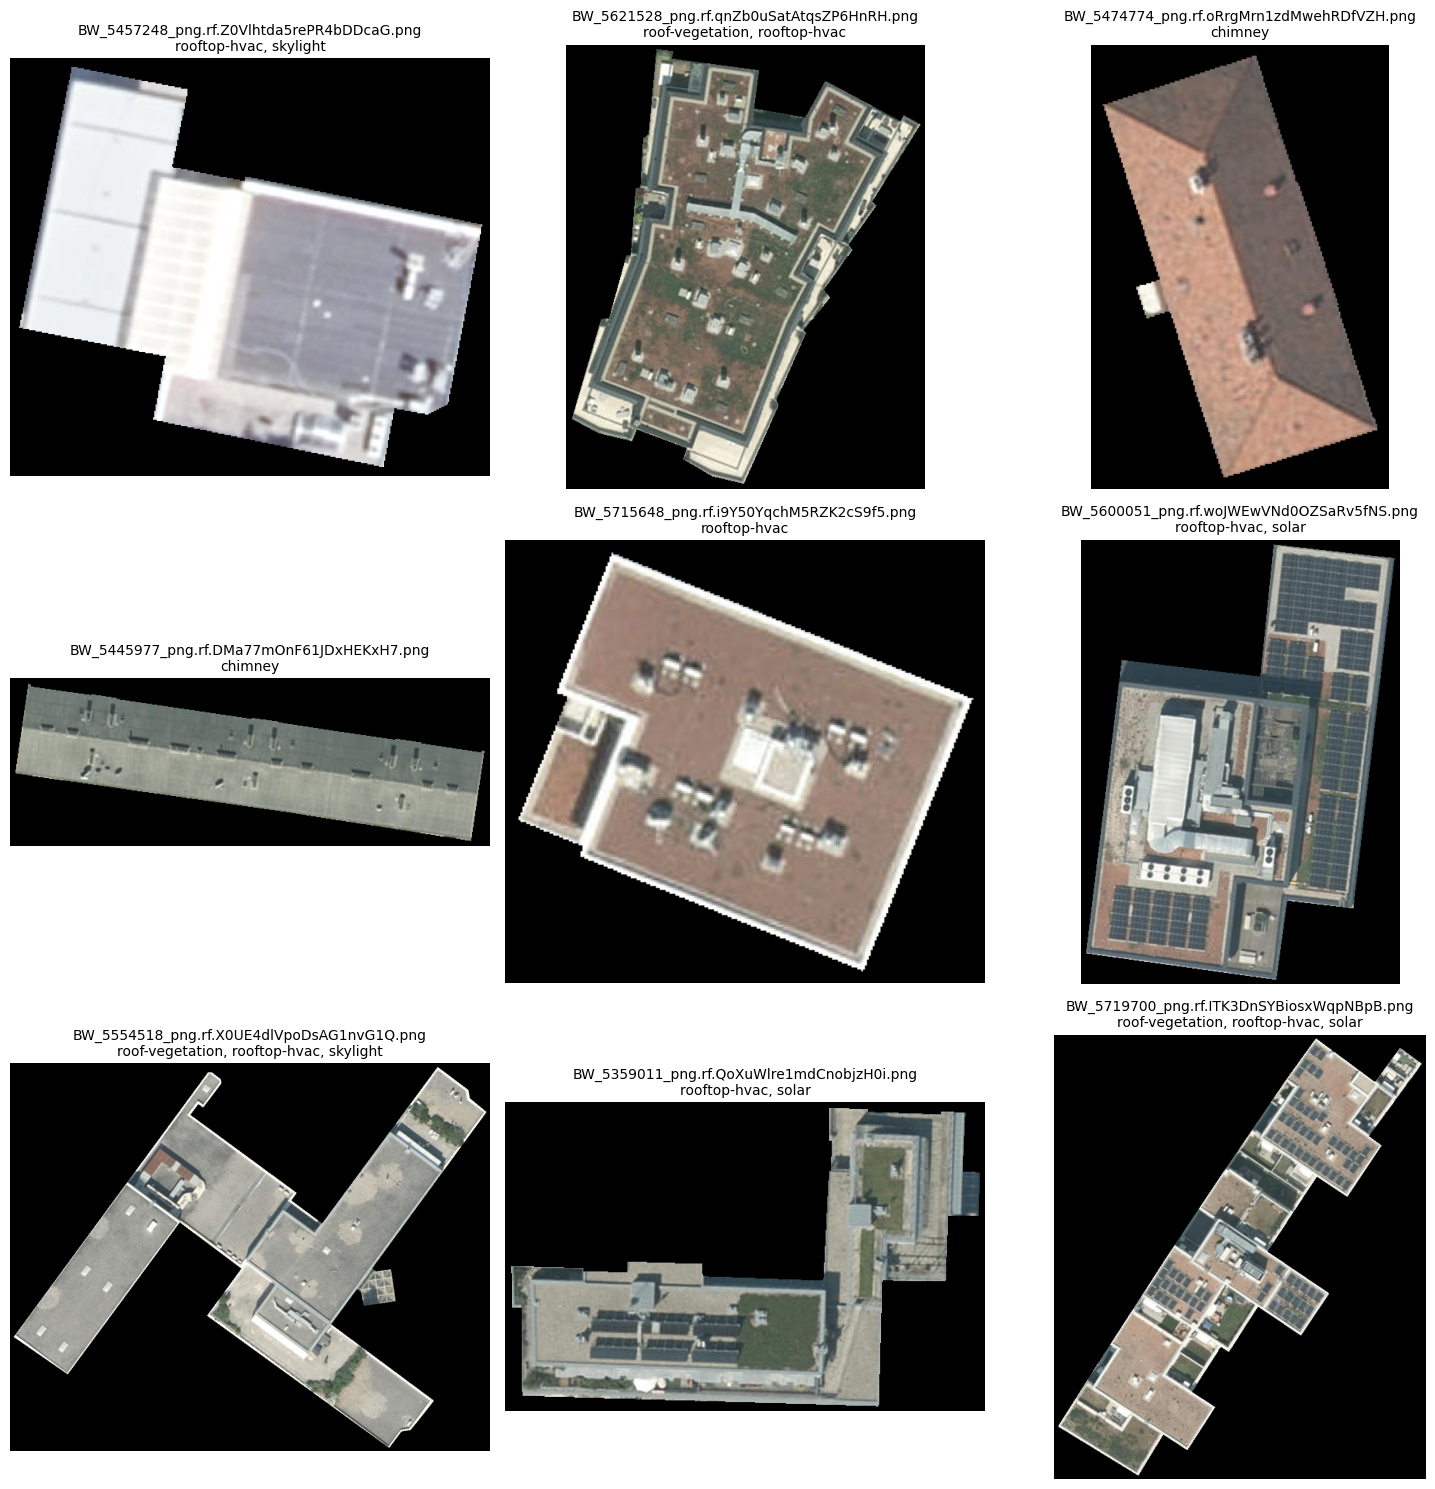

In [25]:
# Number of images to inspect
N_IMAGES = 9

sample_df = df.sample(
    n=min(N_IMAGES, len(df)),
    random_state=42
).reset_index(drop=True)

n_cols = 3
n_rows = (len(sample_df) + n_cols - 1) // n_cols

plt.figure(figsize=(15, 5 * n_rows))

for i, row in sample_df.iterrows():

    image = Image.open(row["image_path"]).convert("RGB")

    active_labels = [
        class_name
        for class_name in class_cols
        if row[class_name] == 1
    ]

    label_text = ", ".join(active_labels)

    if not active_labels:
        label_text = "No positive labels"

    plt.subplot(n_rows, n_cols, i + 1)

    plt.imshow(image)
    plt.axis("off")

    plt.title(
        f"{row['filename']}\n{label_text}",
        fontsize=10
    )

plt.tight_layout()
plt.show()

## 4. Train, validation, and test strategy

The dataset is split using **multilabel stratification**, which is preferable to a simple random split because each image can contain several labels and some features are relatively rare.

The split is performed in two stages:

1. Approximately **15% of the data is held out as a final test set**.
2. The remaining development data is assigned to **5 multilabel-stratified cross-validation folds**.

The held-out test set is intentionally excluded from fold construction and model-selection decisions. It should only be used after the training strategy has been selected.


In [26]:
import random
import numpy as np
import torch

from iterstrat.ml_stratifiers import (
    MultilabelStratifiedShuffleSplit,
    MultilabelStratifiedKFold,
)

# ------------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ------------------------------------------------------------------
# Labels
# ------------------------------------------------------------------

class_cols = [
    "chimney",
    "roof-vegetation",
    "rooftop-hvac",
    "skylight",
    "solar",
]

X = df["image_path"].values
y = df[class_cols].values.astype(np.float32)

print("Total images:", len(df))
print("Classes:", class_cols)

# ------------------------------------------------------------------
# 1. Hold out ~15% as untouched final test set
# ------------------------------------------------------------------

test_splitter = MultilabelStratifiedShuffleSplit(
    n_splits=1,
    test_size=0.15,
    random_state=SEED,
)

dev_idx, test_idx = next(
    test_splitter.split(X, y)
)

dev_df = df.iloc[dev_idx].copy().reset_index(drop=True)
test_df = df.iloc[test_idx].copy().reset_index(drop=True)

print("\nDataset split:")
print("Development:", len(dev_df))
print("Final test: ", len(test_df))

# ------------------------------------------------------------------
# 2. Create 5 multilabel-stratified CV folds
#    ONLY within the development dataset
# ------------------------------------------------------------------

cv = MultilabelStratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED,
)

dev_y = dev_df[class_cols].values.astype(np.float32)

dev_df["fold"] = -1

for fold, (_, val_idx) in enumerate(
    cv.split(
        dev_df["image_path"].values,
        dev_y,
    )
):
    dev_df.loc[val_idx, "fold"] = fold

# ------------------------------------------------------------------
# Verify
# ------------------------------------------------------------------

print("\nFold sizes:")
print(
    dev_df["fold"]
    .value_counts()
    .sort_index()
)

print("\nDevelopment class counts:")
display(
    dev_df[class_cols]
    .sum()
    .rename("positive")
    .to_frame()
)

print("\nFinal test class counts:")
display(
    test_df[class_cols]
    .sum()
    .rename("positive")
    .to_frame()
)

print("\nPositive examples per fold:")

fold_distribution = (
    dev_df
    .groupby("fold")[class_cols]
    .sum()
)

display(fold_distribution)

# ------------------------------------------------------------------
# Sanity checks
# ------------------------------------------------------------------

assert set(dev_idx).isdisjoint(set(test_idx))
assert len(dev_df) + len(test_df) == len(df)
assert (dev_df["fold"] >= 0).all()

print("\n✓ Development and test sets do not overlap")
print("✓ Every development image has a CV fold")
print("✓ Final test set remains untouched")

Total images: 94
Classes: ['chimney', 'roof-vegetation', 'rooftop-hvac', 'skylight', 'solar']

Dataset split:
Development: 81
Final test:  13

Fold sizes:
fold
0    15
1    17
2    16
3    17
4    16
Name: count, dtype: int64

Development class counts:


,positive
chimney,29
roof-vegetation,13
rooftop-hvac,34
skylight,20
solar,33



Final test class counts:


,positive
chimney,5
roof-vegetation,3
rooftop-hvac,7
skylight,4
solar,6



Positive examples per fold:


,chimney,roof-vegetation,rooftop-hvac,skylight,solar
fold,,,,,
0,6,3,7,4,7
1,6,3,7,4,6
2,6,2,7,4,7
3,6,3,6,4,6
4,5,2,7,4,7



✓ Development and test sets do not overlap
✓ Every development image has a CV fold
✓ Final test set remains untouched


## 5. Image preprocessing, augmentation, and PyTorch dataset

The classifier starts from ImageNet-pretrained ResNet18 weights, so images are normalized using the corresponding ImageNet statistics.

Training images receive random rotations of 0°, 90°, 180°, or 270°. Rooftop features are not expected to depend on north-up orientation, and right-angle rotations avoid interpolation and crop artifacts introduced by arbitrary-angle rotation.

Validation and test images use deterministic preprocessing only.


In [27]:
import random

import torch
from torch.utils.data import Dataset
from torchvision import transforms
from torchvision.transforms import functional as TF
from PIL import Image


# ------------------------------------------------------------------
# Rotation augmentation
# ------------------------------------------------------------------

class Random90Rotation:
    """
    Randomly rotate an image by 0, 90, 180, or 270 degrees.

    Appropriate here because rooftop features are orientation-invariant
    and 90-degree rotations avoid interpolation/cropping artifacts.
    """

    def __call__(self, image):
        angle = random.choice([0, 90, 180, 270])
        return TF.rotate(image, angle)


# ------------------------------------------------------------------
# ImageNet normalization
# ------------------------------------------------------------------

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


# Training: rotation augmentation
train_transform = transforms.Compose([
    Random90Rotation(),

    transforms.Resize(
        (224, 224),
        antialias=True,
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD,
    ),
])


# Validation / test: deterministic, no augmentation
eval_transform = transforms.Compose([
    transforms.Resize(
        (224, 224),
        antialias=True,
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD,
    ),
])


# ------------------------------------------------------------------
# Multi-label dataset
# ------------------------------------------------------------------

class RoofFeatureDataset(Dataset):

    def __init__(
        self,
        dataframe,
        class_cols,
        transform=None,
    ):
        self.df = dataframe.reset_index(drop=True).copy()
        self.class_cols = class_cols
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        # Load image
        image = Image.open(
            row["image_path"]
        ).convert("RGB")

        # Apply transform
        if self.transform is not None:
            image = self.transform(image)

        # Multi-label target
        labels = torch.tensor(
            row[self.class_cols]
            .to_numpy(dtype="float32"),
            dtype=torch.float32,
        )

        return image, labels

### 5.1 Dataset sanity check

Before creating the training loaders, one sample is passed through the dataset implementation to verify tensor dimensions, data type, and the correspondence between the label vector and class names.


In [28]:
# ------------------------------------------------------------------
# Test dataset loading
# ------------------------------------------------------------------

example_dataset = RoofFeatureDataset(
    dataframe=dev_df,
    class_cols=class_cols,
    transform=eval_transform,
)

image, labels = example_dataset[0]

print("Number of samples:", len(example_dataset))
print("Image tensor shape:", image.shape)
print("Image dtype:", image.dtype)

print("\nLabel tensor:")
print(labels)

print("\nClasses:")
for class_name, value in zip(class_cols, labels):
    print(f"{class_name:20s}: {int(value.item())}")

Number of samples: 81
Image tensor shape: torch.Size([3, 224, 224])
Image dtype: torch.float32

Label tensor:
tensor([0., 0., 1., 0., 0.])

Classes:
chimney             : 0
roof-vegetation     : 0
rooftop-hvac        : 1
skylight            : 0
solar               : 0


## 6. Fold-specific training data and class weights

For the first development fold, the notebook constructs separate training and validation datasets and loaders.

Class weights are calculated **using the training subset only**. This avoids using validation-label statistics when defining the loss function and therefore keeps the validation fold independent of training decisions.


In [29]:
from torch.utils.data import DataLoader
import torch

# ------------------------------------------------------------------
# Configuration
# ------------------------------------------------------------------

FOLD = 0
BATCH_SIZE = 16

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)
print("Fold:", FOLD)


# ------------------------------------------------------------------
# Split development data into train / validation for this fold
# ------------------------------------------------------------------

train_df = (
    dev_df[dev_df["fold"] != FOLD]
    .copy()
    .reset_index(drop=True)
)

val_df = (
    dev_df[dev_df["fold"] == FOLD]
    .copy()
    .reset_index(drop=True)
)

print("\nSplit sizes:")
print("Train:", len(train_df))
print("Validation:", len(val_df))


# ------------------------------------------------------------------
# Calculate class weights using TRAINING DATA ONLY
# ------------------------------------------------------------------

positive_counts = train_df[class_cols].sum()
negative_counts = len(train_df) - positive_counts

pos_weight = (
    negative_counts / positive_counts
).astype("float32")

print("\nTraining positives:")
display(
    positive_counts
    .rename("positive")
    .to_frame()
)

print("\nPositive class weights:")
display(
    pos_weight
    .rename("pos_weight")
    .to_frame()
)

pos_weight_tensor = torch.tensor(
    pos_weight.values,
    dtype=torch.float32,
    device=device,
)


# ------------------------------------------------------------------
# Create datasets
# ------------------------------------------------------------------

train_dataset = RoofFeatureDataset(
    dataframe=train_df,
    class_cols=class_cols,
    transform=train_transform,
)

val_dataset = RoofFeatureDataset(
    dataframe=val_df,
    class_cols=class_cols,
    transform=eval_transform,
)


# ------------------------------------------------------------------
# Create DataLoaders
# ------------------------------------------------------------------

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,      # safest for Windows notebooks
    pin_memory=torch.cuda.is_available(),
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)


# ------------------------------------------------------------------
# Verify one batch
# ------------------------------------------------------------------

images, labels = next(iter(train_loader))

print("\nBatch shapes:")
print("Images:", images.shape)
print("Labels:", labels.shape)

print("\nFirst label vector:")
print(labels[0])

print("\nClass order:")
print(class_cols)

Device: cuda
Fold: 0

Split sizes:
Train: 66
Validation: 15

Training positives:


,positive
chimney,23
roof-vegetation,10
rooftop-hvac,27
skylight,16
solar,26



Positive class weights:


,pos_weight
chimney,1.869565
roof-vegetation,5.600000
rooftop-hvac,1.444444
skylight,3.125000
solar,1.538462



Batch shapes:
Images: torch.Size([16, 3, 224, 224])
Labels: torch.Size([16, 5])

First label vector:
tensor([0., 1., 1., 1., 0.])

Class order:
['chimney', 'roof-vegetation', 'rooftop-hvac', 'skylight', 'solar']


## 7. Model architecture

A **ResNet18 pretrained on ImageNet** is used as the visual backbone. Its original single-label ImageNet classification head is replaced with a linear layer containing one output logit per rooftop feature.

The loss is `BCEWithLogitsLoss`, which is appropriate for independent binary labels. Sigmoid is applied only when converting logits to probabilities for interpretation and metrics.


In [30]:
import torch
import torch.nn as nn

from torchvision.models import resnet18, ResNet18_Weights


# ------------------------------------------------------------------
# Load pretrained ResNet18
# ------------------------------------------------------------------

weights = ResNet18_Weights.DEFAULT

model = resnet18(
    weights=weights
)


# ------------------------------------------------------------------
# Replace the ImageNet classification head
# ------------------------------------------------------------------

num_features = model.fc.in_features

model.fc = nn.Linear(
    num_features,
    len(class_cols)
)


# ------------------------------------------------------------------
# Freeze the pretrained backbone
# ------------------------------------------------------------------

for param in model.parameters():
    param.requires_grad = False


# ------------------------------------------------------------------
# Fine-tune the final residual block + classifier
# ------------------------------------------------------------------

for param in model.layer4.parameters():
    param.requires_grad = True

for param in model.fc.parameters():
    param.requires_grad = True


# ------------------------------------------------------------------
# Move model to GPU
# ------------------------------------------------------------------

model = model.to(device)


# ------------------------------------------------------------------
# Multi-label weighted loss
# ------------------------------------------------------------------

criterion = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight_tensor
)


# ------------------------------------------------------------------
# Optimizer
# Only parameters with requires_grad=True are optimized
# ------------------------------------------------------------------

optimizer = torch.optim.AdamW(
    filter(
        lambda p: p.requires_grad,
        model.parameters()
    ),
    lr=1e-4,
    weight_decay=1e-4,
)


# ------------------------------------------------------------------
# Show trainable parameter counts
# ------------------------------------------------------------------

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(
    f"Trainable percentage: "
    f"{100 * trainable_params / total_params:.2f}%"
)


# ------------------------------------------------------------------
# Sanity-check forward pass
# ------------------------------------------------------------------

images, labels = next(iter(train_loader))

images = images.to(device)
labels = labels.to(device)

with torch.no_grad():
    logits = model(images)
    probabilities = torch.sigmoid(logits)

print("\nInput shape:")
print(images.shape)

print("\nLogits shape:")
print(logits.shape)

print("\nProbabilities shape:")
print(probabilities.shape)

print("\nExample probabilities:")
for class_name, probability in zip(
    class_cols,
    probabilities[0]
):
    print(
        f"{class_name:20s}: "
        f"{probability.item():.3f}"
    )

Total parameters:     11,179,077
Trainable parameters: 8,396,293
Trainable percentage: 75.11%

Input shape:
torch.Size([16, 3, 224, 224])

Logits shape:
torch.Size([16, 5])

Probabilities shape:
torch.Size([16, 5])

Example probabilities:
chimney             : 0.514
roof-vegetation     : 0.546
rooftop-hvac        : 0.597
skylight            : 0.634
solar               : 0.556


## 8. Stage 1 — train the new classification head

Transfer learning is performed in stages. In Stage 1, the pretrained convolutional backbone is frozen and only the newly initialized classification head is trained.

This provides a stable starting point on the small rooftop dataset before allowing pretrained visual features to change.


In [31]:
# ------------------------------------------------------------------
# Stage 1: freeze entire pretrained backbone
# ------------------------------------------------------------------

for param in model.parameters():
    param.requires_grad = False

# Only the new classification head is trainable
for param in model.fc.parameters():
    param.requires_grad = True


# ------------------------------------------------------------------
# Optimizer for classifier head
# ------------------------------------------------------------------

optimizer = torch.optim.AdamW(
    model.fc.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)


# ------------------------------------------------------------------
# Verify trainable parameters
# ------------------------------------------------------------------

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(
    f"Trainable percentage: "
    f"{100 * trainable_params / total_params:.4f}%"
)

Total parameters:     11,179,077
Trainable parameters: 2,565
Trainable percentage: 0.0229%


### 8.1 Stage 1 optimization and early stopping

Training is monitored using validation **macro average precision (Macro AP)**. Macro AP gives every rooftop-feature class equal importance and is more informative than accuracy for an imbalanced multi-label problem.

The best model state is retained, and early stopping limits unnecessary training once validation performance stops improving.


In [32]:
import copy
import numpy as np
import torch

from sklearn.metrics import (
    average_precision_score,
    f1_score,
)


# ------------------------------------------------------------------
# Training configuration
# ------------------------------------------------------------------

NUM_EPOCHS = 30
PATIENCE = 6
THRESHOLD = 0.5


# ------------------------------------------------------------------
# History
# ------------------------------------------------------------------

history = {
    "train_loss": [],
    "val_loss": [],
    "val_macro_ap": [],
    "val_macro_f1": [],
}


best_macro_ap = -np.inf
best_model_state = None
epochs_without_improvement = 0


# ------------------------------------------------------------------
# Training
# ------------------------------------------------------------------

for epoch in range(1, NUM_EPOCHS + 1):

    # ==============================================================
    # TRAIN
    # ==============================================================

    # Keep frozen backbone in evaluation mode so BatchNorm
    # running statistics are not updated.
    model.eval()

    # But train the newly initialized classification head.
    model.fc.train()

    train_loss = 0.0
    train_samples = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        logits = model(images)

        loss = criterion(
            logits,
            labels
        )

        loss.backward()
        optimizer.step()

        batch_size = images.size(0)

        train_loss += loss.item() * batch_size
        train_samples += batch_size

    train_loss /= train_samples


    # ==============================================================
    # VALIDATION
    # ==============================================================

    model.eval()

    val_loss = 0.0
    val_samples = 0

    all_targets = []
    all_probabilities = []

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)

            loss = criterion(
                logits,
                labels
            )

            probabilities = torch.sigmoid(logits)

            batch_size = images.size(0)

            val_loss += loss.item() * batch_size
            val_samples += batch_size

            all_targets.append(
                labels.cpu().numpy()
            )

            all_probabilities.append(
                probabilities.cpu().numpy()
            )

    val_loss /= val_samples

    y_true = np.concatenate(
        all_targets,
        axis=0
    )

    y_prob = np.concatenate(
        all_probabilities,
        axis=0
    )

    y_pred = (
        y_prob >= THRESHOLD
    ).astype(int)


    # ==============================================================
    # Metrics
    # ==============================================================

    per_class_ap = []

    for i in range(len(class_cols)):

        ap = average_precision_score(
            y_true[:, i],
            y_prob[:, i]
        )

        per_class_ap.append(ap)

    macro_ap = np.mean(per_class_ap)

    macro_f1 = f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0,
    )


    # ==============================================================
    # Save history
    # ==============================================================

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_macro_ap"].append(macro_ap)
    history["val_macro_f1"].append(macro_f1)


    # ==============================================================
    # Best model / early stopping
    # ==============================================================

    improved = macro_ap > best_macro_ap

    if improved:

        best_macro_ap = macro_ap

        best_model_state = copy.deepcopy(
            model.state_dict()
        )

        epochs_without_improvement = 0

    else:

        epochs_without_improvement += 1


    # ==============================================================
    # Progress
    # ==============================================================

    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Macro AP: {macro_ap:.4f} | "
        f"Macro F1: {macro_f1:.4f}"
    )


    # ==============================================================
    # Early stopping
    # ==============================================================

    if epochs_without_improvement >= PATIENCE:

        print(
            f"\nEarly stopping after epoch {epoch}."
        )

        break


# ------------------------------------------------------------------
# Restore best model
# ------------------------------------------------------------------

model.load_state_dict(
    best_model_state
)

print(
    f"\nBest validation Macro AP: "
    f"{best_macro_ap:.4f}"
)

Epoch 01 | Train Loss: 1.0663 | Val Loss: 1.0941 | Macro AP: 0.4088 | Macro F1: 0.3733
Epoch 02 | Train Loss: 0.9816 | Val Loss: 1.1143 | Macro AP: 0.4255 | Macro F1: 0.3747
Epoch 03 | Train Loss: 0.9190 | Val Loss: 1.0588 | Macro AP: 0.4358 | Macro F1: 0.4557
Epoch 04 | Train Loss: 0.8647 | Val Loss: 1.0464 | Macro AP: 0.4706 | Macro F1: 0.3464
Epoch 05 | Train Loss: 0.8497 | Val Loss: 1.0557 | Macro AP: 0.5067 | Macro F1: 0.3256
Epoch 06 | Train Loss: 0.8220 | Val Loss: 1.0359 | Macro AP: 0.5297 | Macro F1: 0.4398
Epoch 07 | Train Loss: 0.7743 | Val Loss: 1.0272 | Macro AP: 0.5199 | Macro F1: 0.5012
Epoch 08 | Train Loss: 0.7303 | Val Loss: 1.0186 | Macro AP: 0.5393 | Macro F1: 0.5367
Epoch 09 | Train Loss: 0.7158 | Val Loss: 1.0200 | Macro AP: 0.5623 | Macro F1: 0.5155
Epoch 10 | Train Loss: 0.6944 | Val Loss: 1.0340 | Macro AP: 0.5597 | Macro F1: 0.4798
Epoch 11 | Train Loss: 0.6472 | Val Loss: 1.0454 | Macro AP: 0.5611 | Macro F1: 0.4376
Epoch 12 | Train Loss: 0.6661 | Val Loss: 1

### 8.2 Stage 1 diagnostics

Learning curves and per-class metrics are inspected after Stage 1. Precision, recall, F1, and average precision are reported per feature, while Macro AP summarizes ranking performance across classes.

A fixed probability threshold of `0.5` is used here for binary predictions; the raw sigmoid values should be interpreted as model scores rather than calibrated confidence estimates.


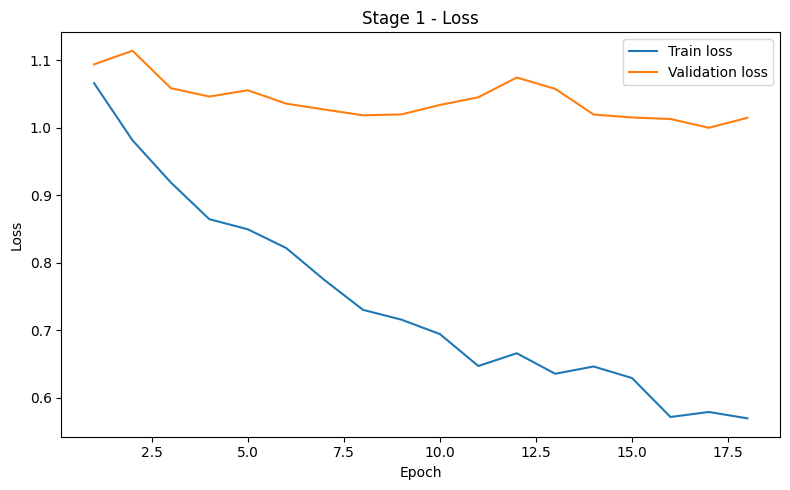

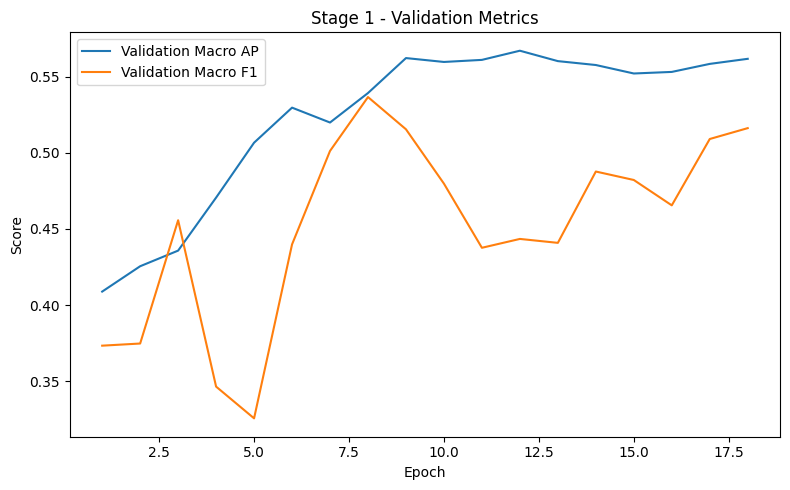

,class,positives,AP,precision,recall,F1
0,chimney,6,0.813,0.750,0.500,0.600
1,roof-vegetation,3,0.289,0.000,0.000,0.000
2,rooftop-hvac,7,0.685,0.700,1.000,0.824
3,skylight,4,0.496,0.200,0.250,0.222
4,solar,7,0.552,0.571,0.571,0.571


Macro AP: 0.567
Macro F1: 0.443
Micro F1: 0.556


In [33]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import (
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
)

# ------------------------------------------------------------------
# 1. Learning curves
# ------------------------------------------------------------------

epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history["train_loss"],
    label="Train loss",
)

plt.plot(
    epochs,
    history["val_loss"],
    label="Validation loss",
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Stage 1 - Loss")
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history["val_macro_ap"],
    label="Validation Macro AP",
)

plt.plot(
    epochs,
    history["val_macro_f1"],
    label="Validation Macro F1",
)

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Stage 1 - Validation Metrics")
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------------
# 2. Run best model on validation set
# ------------------------------------------------------------------

model.eval()

all_targets = []
all_probabilities = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)

        logits = model(images)
        probabilities = torch.sigmoid(logits)

        all_targets.append(
            labels.numpy()
        )

        all_probabilities.append(
            probabilities.cpu().numpy()
        )

y_true = np.concatenate(
    all_targets,
    axis=0,
)

y_prob = np.concatenate(
    all_probabilities,
    axis=0,
)

# Fixed threshold for now
y_pred = (
    y_prob >= 0.5
).astype(int)


# ------------------------------------------------------------------
# 3. Per-class metrics
# ------------------------------------------------------------------

results = []

for i, class_name in enumerate(class_cols):

    ap = average_precision_score(
        y_true[:, i],
        y_prob[:, i],
    )

    precision = precision_score(
        y_true[:, i],
        y_pred[:, i],
        zero_division=0,
    )

    recall = recall_score(
        y_true[:, i],
        y_pred[:, i],
        zero_division=0,
    )

    f1 = f1_score(
        y_true[:, i],
        y_pred[:, i],
        zero_division=0,
    )

    results.append({
        "class": class_name,
        "positives": int(y_true[:, i].sum()),
        "AP": ap,
        "precision": precision,
        "recall": recall,
        "F1": f1,
    })


results_df = pd.DataFrame(results)

display(
    results_df.style.format({
        "AP": "{:.3f}",
        "precision": "{:.3f}",
        "recall": "{:.3f}",
        "F1": "{:.3f}",
    })
)


# ------------------------------------------------------------------
# 4. Overall metrics
# ------------------------------------------------------------------

macro_ap = results_df["AP"].mean()

macro_f1 = f1_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0,
)

micro_f1 = f1_score(
    y_true,
    y_pred,
    average="micro",
    zero_division=0,
)

print(f"Macro AP: {macro_ap:.3f}")
print(f"Macro F1: {macro_f1:.3f}")
print(f"Micro F1: {micro_f1:.3f}")

## 9. Stage 2 — fine-tune the final ResNet block

Stage 2 starts from the best Stage 1 checkpoint and unfreezes `layer4`, the final residual block of ResNet18.

A smaller learning rate is used for pretrained convolutional weights than for the classification head. Batch-normalization running statistics remain frozen because the dataset and batch sizes are small, which reduces the risk of unstable updates.

Stage 2 is accepted only when it improves validation Macro AP over Stage 1.


In [34]:
import copy
import numpy as np
import torch
import torch.nn as nn

from sklearn.metrics import (
    average_precision_score,
    f1_score,
)

# ------------------------------------------------------------------
# Stage 2 configuration
# ------------------------------------------------------------------

NUM_EPOCHS_STAGE2 = 20
PATIENCE_STAGE2 = 5
THRESHOLD = 0.5


# ------------------------------------------------------------------
# Unfreeze layer4
# ------------------------------------------------------------------

for param in model.layer4.parameters():
    param.requires_grad = True

for param in model.fc.parameters():
    param.requires_grad = True


# ------------------------------------------------------------------
# Different learning rates
#
# pretrained layer4 -> very small LR
# newly trained head -> slightly larger LR
# ------------------------------------------------------------------

optimizer = torch.optim.AdamW(
    [
        {
            "params": model.layer4.parameters(),
            "lr": 1e-5,
        },
        {
            "params": model.fc.parameters(),
            "lr": 1e-4,
        },
    ],
    weight_decay=1e-4,
)


# ------------------------------------------------------------------
# Keep BatchNorm running statistics frozen
#
# Important for such a small dataset.
# We still train convolutional weights in layer4.
# ------------------------------------------------------------------

def freeze_batchnorm_stats(model):
    for module in model.modules():
        if isinstance(module, nn.BatchNorm2d):
            module.eval()


# ------------------------------------------------------------------
# Track Stage 2 separately
# ------------------------------------------------------------------

stage2_history = {
    "train_loss": [],
    "val_loss": [],
    "val_macro_ap": [],
    "val_macro_f1": [],
}

# Start with Stage 1 performance as the benchmark.
# Stage 2 is only accepted if it improves validation Macro AP.
stage1_best_ap = best_macro_ap

stage2_best_ap = stage1_best_ap
stage2_best_state = copy.deepcopy(model.state_dict())

epochs_without_improvement = 0


# ------------------------------------------------------------------
# Fine-tuning loop
# ------------------------------------------------------------------

for epoch in range(1, NUM_EPOCHS_STAGE2 + 1):

    # ==============================================================
    # TRAIN
    # ==============================================================

    model.train()

    # Prevent unstable BatchNorm updates on tiny batches/dataset
    freeze_batchnorm_stats(model)

    train_loss = 0.0
    train_samples = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        logits = model(images)

        loss = criterion(
            logits,
            labels,
        )

        loss.backward()
        optimizer.step()

        batch_size = images.size(0)

        train_loss += loss.item() * batch_size
        train_samples += batch_size

    train_loss /= train_samples


    # ==============================================================
    # VALIDATION
    # ==============================================================

    model.eval()

    val_loss = 0.0
    val_samples = 0

    all_targets = []
    all_probabilities = []

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)

            loss = criterion(
                logits,
                labels,
            )

            probabilities = torch.sigmoid(logits)

            batch_size = images.size(0)

            val_loss += loss.item() * batch_size
            val_samples += batch_size

            all_targets.append(
                labels.cpu().numpy()
            )

            all_probabilities.append(
                probabilities.cpu().numpy()
            )

    val_loss /= val_samples

    y_true = np.concatenate(
        all_targets,
        axis=0,
    )

    y_prob = np.concatenate(
        all_probabilities,
        axis=0,
    )

    y_pred = (
        y_prob >= THRESHOLD
    ).astype(int)


    # ==============================================================
    # Metrics
    # ==============================================================

    per_class_ap = []

    for i in range(len(class_cols)):

        ap = average_precision_score(
            y_true[:, i],
            y_prob[:, i],
        )

        per_class_ap.append(ap)

    macro_ap = np.mean(per_class_ap)

    macro_f1 = f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0,
    )


    # ==============================================================
    # History
    # ==============================================================

    stage2_history["train_loss"].append(train_loss)
    stage2_history["val_loss"].append(val_loss)
    stage2_history["val_macro_ap"].append(macro_ap)
    stage2_history["val_macro_f1"].append(macro_f1)


    # ==============================================================
    # Checkpoint
    # ==============================================================

    if macro_ap > stage2_best_ap:

        stage2_best_ap = macro_ap

        stage2_best_state = copy.deepcopy(
            model.state_dict()
        )

        epochs_without_improvement = 0

    else:

        epochs_without_improvement += 1


    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Macro AP: {macro_ap:.4f} | "
        f"Macro F1: {macro_f1:.4f}"
    )


    if epochs_without_improvement >= PATIENCE_STAGE2:

        print(
            f"\nEarly stopping after epoch {epoch}."
        )

        break


# ------------------------------------------------------------------
# Restore best model found across Stage 1 / Stage 2
# ------------------------------------------------------------------

model.load_state_dict(
    stage2_best_state
)

print(f"\nStage 1 best Macro AP: {stage1_best_ap:.4f}")
print(f"Best after Stage 2:     {stage2_best_ap:.4f}")

if stage2_best_ap > stage1_best_ap:
    print("✓ Fine-tuning improved validation performance.")
else:
    print("→ Fine-tuning did not improve on the frozen-backbone baseline.")

Epoch 01 | Train Loss: 0.6447 | Val Loss: 1.0315 | Macro AP: 0.5658 | Macro F1: 0.4822
Epoch 02 | Train Loss: 0.5969 | Val Loss: 1.0437 | Macro AP: 0.5658 | Macro F1: 0.5231
Epoch 03 | Train Loss: 0.5546 | Val Loss: 1.0948 | Macro AP: 0.5810 | Macro F1: 0.4762
Epoch 04 | Train Loss: 0.4914 | Val Loss: 1.1345 | Macro AP: 0.5654 | Macro F1: 0.4705
Epoch 05 | Train Loss: 0.4819 | Val Loss: 1.1390 | Macro AP: 0.5719 | Macro F1: 0.4667
Epoch 06 | Train Loss: 0.4547 | Val Loss: 1.1393 | Macro AP: 0.5719 | Macro F1: 0.5429
Epoch 07 | Train Loss: 0.4182 | Val Loss: 1.1728 | Macro AP: 0.5738 | Macro F1: 0.4564
Epoch 08 | Train Loss: 0.4007 | Val Loss: 1.2376 | Macro AP: 0.5897 | Macro F1: 0.4333
Epoch 09 | Train Loss: 0.3899 | Val Loss: 1.2956 | Macro AP: 0.6135 | Macro F1: 0.4769
Epoch 10 | Train Loss: 0.3600 | Val Loss: 1.2477 | Macro AP: 0.6213 | Macro F1: 0.4769
Epoch 11 | Train Loss: 0.3391 | Val Loss: 1.1939 | Macro AP: 0.6279 | Macro F1: 0.4955
Epoch 12 | Train Loss: 0.3066 | Val Loss: 1

### 9.1 Stage 2 validation

The best Stage 2 checkpoint is evaluated on the validation fold using the same metrics as Stage 1. This makes the comparison between head-only training and partial backbone fine-tuning explicit.


In [35]:
from sklearn.metrics import (
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
)

# ------------------------------------------------------------------
# Evaluate best Stage 2 model on Fold 0 validation set
# ------------------------------------------------------------------

model.eval()

all_targets = []
all_probabilities = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)

        logits = model(images)
        probabilities = torch.sigmoid(logits)

        all_targets.append(labels.numpy())
        all_probabilities.append(
            probabilities.cpu().numpy()
        )

y_true_stage2 = np.concatenate(
    all_targets,
    axis=0,
)

y_prob_stage2 = np.concatenate(
    all_probabilities,
    axis=0,
)

y_pred_stage2 = (
    y_prob_stage2 >= 0.5
).astype(int)


# ------------------------------------------------------------------
# Per-class metrics
# ------------------------------------------------------------------

stage2_results = []

for i, class_name in enumerate(class_cols):

    stage2_results.append({
        "class": class_name,
        "positives": int(
            y_true_stage2[:, i].sum()
        ),
        "AP": average_precision_score(
            y_true_stage2[:, i],
            y_prob_stage2[:, i],
        ),
        "precision": precision_score(
            y_true_stage2[:, i],
            y_pred_stage2[:, i],
            zero_division=0,
        ),
        "recall": recall_score(
            y_true_stage2[:, i],
            y_pred_stage2[:, i],
            zero_division=0,
        ),
        "F1": f1_score(
            y_true_stage2[:, i],
            y_pred_stage2[:, i],
            zero_division=0,
        ),
    })

stage2_results_df = pd.DataFrame(
    stage2_results
)

display(
    stage2_results_df.style.format({
        "AP": "{:.3f}",
        "precision": "{:.3f}",
        "recall": "{:.3f}",
        "F1": "{:.3f}",
    })
)

print(
    "Macro AP:",
    round(stage2_results_df["AP"].mean(), 3)
)

print(
    "Macro F1:",
    round(
        f1_score(
            y_true_stage2,
            y_pred_stage2,
            average="macro",
            zero_division=0,
        ),
        3,
    )
)

print(
    "Micro F1:",
    round(
        f1_score(
            y_true_stage2,
            y_pred_stage2,
            average="micro",
            zero_division=0,
        ),
        3,
    )
)

,class,positives,AP,precision,recall,F1
0,chimney,6,0.889,1.000,0.500,0.667
1,roof-vegetation,3,0.349,0.000,0.000,0.000
2,rooftop-hvac,7,0.597,0.667,0.571,0.615
3,skylight,4,0.533,0.333,0.500,0.400
4,solar,7,0.816,0.750,0.857,0.800


Macro AP: 0.637
Macro F1: 0.496
Micro F1: 0.577


## 10. Full 5-fold cross-validation

The previous cells demonstrate the training procedure on a single fold. The following implementation packages the same logic into a reusable function and repeats it across all five development folds.

For every fold:

- a fresh pretrained ResNet18 is initialized;
- positive-class weights are calculated from that fold's training subset;
- Stage 1 trains the classifier head;
- Stage 2 optionally fine-tunes `layer4`;
- the better stage is selected using validation Macro AP;
- fold-level and per-class metrics are retained.

This provides a more robust estimate of performance than relying on one train/validation split.


In [36]:
import copy
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from torch.utils.data import DataLoader
from torchvision.models import resnet18, ResNet18_Weights

from sklearn.metrics import (
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
)


# ------------------------------------------------------------------
# Configuration
# ------------------------------------------------------------------

BATCH_SIZE = 16

STAGE1_EPOCHS = 30
STAGE1_PATIENCE = 6

STAGE2_EPOCHS = 20
STAGE2_PATIENCE = 5

THRESHOLD = 0.5
SEED = 42


# ------------------------------------------------------------------
# Reproducibility helper
# ------------------------------------------------------------------

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


# ------------------------------------------------------------------
# BatchNorm helper
# ------------------------------------------------------------------

def freeze_batchnorm_stats(model):
    for module in model.modules():
        if isinstance(module, nn.BatchNorm2d):
            module.eval()


# ------------------------------------------------------------------
# Evaluation helper
# ------------------------------------------------------------------

def evaluate_model(
    model,
    loader,
    criterion,
    device,
    class_cols,
    threshold=0.5,
):

    model.eval()

    total_loss = 0.0
    total_samples = 0

    all_targets = []
    all_probs = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)

            loss = criterion(
                logits,
                labels,
            )

            probs = torch.sigmoid(logits)

            batch_size = images.size(0)

            total_loss += loss.item() * batch_size
            total_samples += batch_size

            all_targets.append(
                labels.cpu().numpy()
            )

            all_probs.append(
                probs.cpu().numpy()
            )

    y_true = np.concatenate(
        all_targets,
        axis=0,
    )

    y_prob = np.concatenate(
        all_probs,
        axis=0,
    )

    y_pred = (
        y_prob >= threshold
    ).astype(int)

    per_class_ap = []

    for i in range(len(class_cols)):

        ap = average_precision_score(
            y_true[:, i],
            y_prob[:, i],
        )

        per_class_ap.append(ap)

    macro_ap = np.mean(per_class_ap)

    macro_f1 = f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0,
    )

    return {
        "loss": total_loss / total_samples,
        "macro_ap": macro_ap,
        "macro_f1": macro_f1,
        "per_class_ap": per_class_ap,
        "y_true": y_true,
        "y_prob": y_prob,
        "y_pred": y_pred,
    }


# ------------------------------------------------------------------
# Train one fold
# ------------------------------------------------------------------
def train_fold(
    fold,
    dev_df,
    class_cols,
    train_transform,
    eval_transform,
    device,
):

    print("\n" + "=" * 70)
    print(f"FOLD {fold}")
    print("=" * 70)

    set_seed(SEED + fold)

    # --------------------------------------------------------------
    # Train / validation split
    # --------------------------------------------------------------

    train_df = (
        dev_df[dev_df["fold"] != fold]
        .copy()
        .reset_index(drop=True)
    )

    val_df = (
        dev_df[dev_df["fold"] == fold]
        .copy()
        .reset_index(drop=True)
    )

    print(
        f"Train: {len(train_df)} | "
        f"Validation: {len(val_df)}"
    )

    # --------------------------------------------------------------
    # Class weights from training data ONLY
    # --------------------------------------------------------------

    positive_counts = train_df[class_cols].sum()
    negative_counts = len(train_df) - positive_counts

    pos_weight = (
        negative_counts / positive_counts
    ).astype("float32")

    pos_weight_tensor = torch.tensor(
        pos_weight.values,
        dtype=torch.float32,
        device=device,
    )

    # --------------------------------------------------------------
    # Datasets
    # --------------------------------------------------------------

    train_dataset = RoofFeatureDataset(
        train_df,
        class_cols,
        transform=train_transform,
    )

    val_dataset = RoofFeatureDataset(
        val_df,
        class_cols,
        transform=eval_transform,
    )

    # --------------------------------------------------------------
    # DataLoaders
    # --------------------------------------------------------------

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )

    # --------------------------------------------------------------
    # Fresh pretrained model for each fold
    # --------------------------------------------------------------

    model = resnet18(
        weights=ResNet18_Weights.DEFAULT
    )

    model.fc = nn.Linear(
        model.fc.in_features,
        len(class_cols),
    )

    model = model.to(device)

    criterion = nn.BCEWithLogitsLoss(
        pos_weight=pos_weight_tensor
    )

    # ==============================================================
    # STAGE 1 — train classifier head only
    # ==============================================================

    for param in model.parameters():
        param.requires_grad = False

    for param in model.fc.parameters():
        param.requires_grad = True

    optimizer = torch.optim.AdamW(
        model.fc.parameters(),
        lr=1e-3,
        weight_decay=1e-4,
    )

    best_stage1_ap = -np.inf
    best_stage1_state = None
    best_stage1_epoch = None

    epochs_without_improvement = 0

    for epoch in range(1, STAGE1_EPOCHS + 1):

        model.eval()
        model.fc.train()

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            logits = model(images)

            loss = criterion(
                logits,
                labels,
            )

            loss.backward()
            optimizer.step()

        metrics = evaluate_model(
            model,
            val_loader,
            criterion,
            device,
            class_cols,
            THRESHOLD,
        )

        if metrics["macro_ap"] > best_stage1_ap:

            best_stage1_ap = metrics["macro_ap"]

            best_stage1_state = copy.deepcopy(
                model.state_dict()
            )

            best_stage1_epoch = epoch

            epochs_without_improvement = 0

        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= STAGE1_PATIENCE:
            break

    print(
        f"Stage 1: AP={best_stage1_ap:.3f} "
        f"at epoch {best_stage1_epoch}"
    )

    # Restore best Stage 1 checkpoint before Stage 2
    model.load_state_dict(
        best_stage1_state
    )

    # ==============================================================
    # STAGE 2 — fine-tune layer4
    # ==============================================================

    for param in model.layer4.parameters():
        param.requires_grad = True

    for param in model.fc.parameters():
        param.requires_grad = True

    optimizer = torch.optim.AdamW(
        [
            {
                "params": model.layer4.parameters(),
                "lr": 1e-5,
            },
            {
                "params": model.fc.parameters(),
                "lr": 1e-4,
            },
        ],
        weight_decay=1e-4,
    )

    # IMPORTANT:
    # Track Stage 2 independently from Stage 1
    best_stage2_ap = -np.inf
    best_stage2_state = None
    best_stage2_epoch = None

    epochs_without_improvement = 0

    for epoch in range(1, STAGE2_EPOCHS + 1):

        model.train()

        freeze_batchnorm_stats(model)

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            logits = model(images)

            loss = criterion(
                logits,
                labels,
            )

            loss.backward()
            optimizer.step()

        metrics = evaluate_model(
            model,
            val_loader,
            criterion,
            device,
            class_cols,
            THRESHOLD,
        )

        if metrics["macro_ap"] > best_stage2_ap:

            best_stage2_ap = metrics["macro_ap"]

            best_stage2_state = copy.deepcopy(
                model.state_dict()
            )

            best_stage2_epoch = epoch

            epochs_without_improvement = 0

        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= STAGE2_PATIENCE:
            break

    print(
        f"Stage 2: AP={best_stage2_ap:.3f} "
        f"at epoch {best_stage2_epoch}"
    )

    # ==============================================================
    # Select best strategy for this fold
    # ==============================================================

    if best_stage2_ap > best_stage1_ap:

        selected_state = best_stage2_state
        selected_ap = best_stage2_ap
        selected_stage = "stage2"

    else:

        selected_state = best_stage1_state
        selected_ap = best_stage1_ap
        selected_stage = "stage1"

    model.load_state_dict(
        selected_state
    )

    final_metrics = evaluate_model(
        model,
        val_loader,
        criterion,
        device,
        class_cols,
        THRESHOLD,
    )

    print(
        f"Selected: {selected_stage} | "
        f"AP={selected_ap:.3f}"
    )

    # --------------------------------------------------------------
    # Per-class results
    # --------------------------------------------------------------

    fold_results = []

    for i, class_name in enumerate(class_cols):

        fold_results.append({
            "fold": fold,
            "class": class_name,

            "positives": int(
                final_metrics["y_true"][:, i].sum()
            ),

            "AP": average_precision_score(
                final_metrics["y_true"][:, i],
                final_metrics["y_prob"][:, i],
            ),

            "precision": precision_score(
                final_metrics["y_true"][:, i],
                final_metrics["y_pred"][:, i],
                zero_division=0,
            ),

            "recall": recall_score(
                final_metrics["y_true"][:, i],
                final_metrics["y_pred"][:, i],
                zero_division=0,
            ),

            "F1": f1_score(
                final_metrics["y_true"][:, i],
                final_metrics["y_pred"][:, i],
                zero_division=0,
            ),
        })

    fold_summary = {
        "fold": fold,

        "stage1_macro_ap": best_stage1_ap,
        "stage1_best_epoch": best_stage1_epoch,

        "stage2_macro_ap": best_stage2_ap,
        "stage2_best_epoch": best_stage2_epoch,

        "selected_macro_ap": selected_ap,
        "selected_stage": selected_stage,

        "selected_macro_f1": final_metrics["macro_f1"],
    }

    return (
        fold_results,
        fold_summary,
        selected_state,
    )

In [37]:
all_class_results = []
all_fold_summaries = []
fold_states = {}

for fold in range(5):

    fold_results, fold_summary, fold_state = train_fold(
        fold=fold,
        dev_df=dev_df,
        class_cols=class_cols,
        train_transform=train_transform,
        eval_transform=eval_transform,
        device=device,
    )

    all_class_results.extend(fold_results)
    all_fold_summaries.append(fold_summary)
    fold_states[fold] = fold_state


FOLD 0
Train: 66 | Validation: 15
Stage 1: AP=0.616 at epoch 30
Stage 2: AP=0.664 at epoch 7
Selected: stage2 | AP=0.664

FOLD 1
Train: 64 | Validation: 17
Stage 1: AP=0.675 at epoch 12
Stage 2: AP=0.710 at epoch 7
Selected: stage2 | AP=0.710

FOLD 2
Train: 65 | Validation: 16
Stage 1: AP=0.756 at epoch 17
Stage 2: AP=0.761 at epoch 5
Selected: stage2 | AP=0.761

FOLD 3
Train: 64 | Validation: 17
Stage 1: AP=0.807 at epoch 9
Stage 2: AP=0.813 at epoch 1
Selected: stage2 | AP=0.813

FOLD 4
Train: 65 | Validation: 16
Stage 1: AP=0.673 at epoch 24
Stage 2: AP=0.814 at epoch 19
Selected: stage2 | AP=0.814


### 10.1 Fold-level results

This table compares Stage 1 and Stage 2 across the five folds and records which strategy was selected for each fold. Variation between folds is useful for judging how sensitive the model is to the limited training sample.


In [38]:
cv_summary_df = pd.DataFrame(
    all_fold_summaries
)

display(
    cv_summary_df.style.format({
        "stage1_macro_ap": "{:.3f}",
        "stage2_macro_ap": "{:.3f}",
        "selected_macro_ap": "{:.3f}",
        "selected_macro_f1": "{:.3f}",
    })
)

,fold,stage1_macro_ap,stage1_best_epoch,stage2_macro_ap,stage2_best_epoch,selected_macro_ap,selected_stage,selected_macro_f1
0,0,0.616,30,0.664,7,0.664,stage2,0.498
1,1,0.675,12,0.710,7,0.710,stage2,0.556
2,2,0.756,17,0.761,5,0.761,stage2,0.710
3,3,0.807,9,0.813,1,0.813,stage2,0.719
4,4,0.673,24,0.814,19,0.814,stage2,0.688


### 10.2 Per-class cross-validation summary

Per-class metrics are aggregated across folds to show both average performance and variability. This is especially important for classes with fewer positive examples, where a single aggregate score can hide unstable behavior.


In [39]:
class_results_df = pd.DataFrame(
    all_class_results
)

class_cv_summary = (
    class_results_df
    .groupby("class")
    .agg(
        AP_mean=("AP", "mean"),
        AP_std=("AP", "std"),
        precision_mean=("precision", "mean"),
        recall_mean=("recall", "mean"),
        F1_mean=("F1", "mean"),
    )
    .sort_values(
        "AP_mean",
        ascending=False,
    )
)

display(
    class_cv_summary.style.format({
        "AP_mean": "{:.3f}",
        "AP_std": "{:.3f}",
        "precision_mean": "{:.3f}",
        "recall_mean": "{:.3f}",
        "F1_mean": "{:.3f}",
    })
)

,AP_mean,AP_std,precision_mean,recall_mean,F1_mean
class,,,,,
solar,0.886,0.035,0.712,0.724,0.710
chimney,0.868,0.047,0.673,0.820,0.726
rooftop-hvac,0.759,0.104,0.685,0.648,0.662
roof-vegetation,0.725,0.274,0.633,0.567,0.568
skylight,0.523,0.093,0.431,0.650,0.506


## 11. Final model training, held-out evaluation & export

Cross-validation above is used only to choose how long to train, not to produce the deployed model. The steps below select the training length from the CV folds, retrain one model on the **entire** development set, evaluate it once on the untouched test set, and save it with the metadata needed to reload and run it later.


### 11.1 Select final training length from cross-validation

Use the median best epoch across folds for each stage, rather than trusting any single fold.


In [ ]:
# ================================================================
# FINAL EPOCH SELECTION (from cross-validation)
# ================================================================

FINAL_STAGE1_EPOCHS = max(
    1,
    int(cv_summary_df["stage1_best_epoch"].median())
)

FINAL_STAGE2_EPOCHS = max(
    1,
    int(cv_summary_df["stage2_best_epoch"].median())
)

print(f"Final Stage 1 epochs: {FINAL_STAGE1_EPOCHS}")
print(f"Final Stage 2 epochs: {FINAL_STAGE2_EPOCHS}")


### 11.2 Train the final model on the full development set

A fresh ResNet18 is trained on all development data (every CV fold combined), using the epoch counts selected above. The five per-fold models from cross-validation are discarded — they only existed to estimate performance and the right training length.


In [ ]:
# ================================================================
# FINAL MODEL TRAINING (full development set)
# ================================================================

set_seed(SEED)

final_train_dataset = RoofFeatureDataset(
    dataframe=dev_df,
    class_cols=class_cols,
    transform=train_transform,
)

final_train_loader = DataLoader(
    final_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

# Class weights from the full development set (not a single fold)
positive_counts = dev_df[class_cols].sum()
negative_counts = len(dev_df) - positive_counts
final_pos_weight = (negative_counts / positive_counts).astype("float32")

final_pos_weight_tensor = torch.tensor(
    final_pos_weight.values,
    dtype=torch.float32,
    device=device,
)

final_criterion = nn.BCEWithLogitsLoss(pos_weight=final_pos_weight_tensor)

final_model = resnet18(weights=ResNet18_Weights.DEFAULT)
final_model.fc = nn.Linear(final_model.fc.in_features, len(class_cols))
final_model = final_model.to(device)

# ------------------------------------------------------------------
# Stage 1 - classifier head only
# ------------------------------------------------------------------

for param in final_model.parameters():
    param.requires_grad = False

for param in final_model.fc.parameters():
    param.requires_grad = True

optimizer = torch.optim.AdamW(
    final_model.fc.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)

print("Stage 1")

for epoch in range(1, FINAL_STAGE1_EPOCHS + 1):

    final_model.eval()
    final_model.fc.train()

    epoch_loss = 0.0
    epoch_samples = 0

    for images, labels in final_train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        logits = final_model(images)
        loss = final_criterion(logits, labels)

        loss.backward()
        optimizer.step()

        batch_size = images.size(0)
        epoch_loss += loss.item() * batch_size
        epoch_samples += batch_size

    print(f"Epoch {epoch:02d}/{FINAL_STAGE1_EPOCHS} | Loss: {epoch_loss / epoch_samples:.4f}")

# ------------------------------------------------------------------
# Stage 2 - fine-tune layer4 + head
# ------------------------------------------------------------------

for param in final_model.layer4.parameters():
    param.requires_grad = True

for param in final_model.fc.parameters():
    param.requires_grad = True

optimizer = torch.optim.AdamW(
    [
        {"params": final_model.layer4.parameters(), "lr": 1e-5},
        {"params": final_model.fc.parameters(), "lr": 1e-4},
    ],
    weight_decay=1e-4,
)

print("\nStage 2")

for epoch in range(1, FINAL_STAGE2_EPOCHS + 1):

    final_model.train()
    freeze_batchnorm_stats(final_model)

    epoch_loss = 0.0
    epoch_samples = 0

    for images, labels in final_train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        logits = final_model(images)
        loss = final_criterion(logits, labels)

        loss.backward()
        optimizer.step()

        batch_size = images.size(0)
        epoch_loss += loss.item() * batch_size
        epoch_samples += batch_size

    print(f"Epoch {epoch:02d}/{FINAL_STAGE2_EPOCHS} | Loss: {epoch_loss / epoch_samples:.4f}")

print("\nFinal model training complete.")


### 11.3 Evaluate the final model on the untouched test set

This is the first and only time `test_df` is used. It was held out before cross-validation began, so this gives an unbiased read on generalization.


In [ ]:
# ================================================================
# HELD-OUT TEST EVALUATION
# ================================================================

test_dataset = RoofFeatureDataset(
    dataframe=test_df,
    class_cols=class_cols,
    transform=eval_transform,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

final_model.eval()

all_targets = []
all_probabilities = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        logits = final_model(images)
        probabilities = torch.sigmoid(logits)

        all_targets.append(labels.numpy())
        all_probabilities.append(probabilities.cpu().numpy())

y_true = np.concatenate(all_targets, axis=0)
y_prob = np.concatenate(all_probabilities, axis=0)
y_pred = (y_prob >= THRESHOLD).astype(int)

test_results = []

for i, class_name in enumerate(class_cols):

    test_results.append({
        "class": class_name,
        "positives": int(y_true[:, i].sum()),
        "AP": average_precision_score(y_true[:, i], y_prob[:, i]),
        "precision": precision_score(y_true[:, i], y_pred[:, i], zero_division=0),
        "recall": recall_score(y_true[:, i], y_pred[:, i], zero_division=0),
        "F1": f1_score(y_true[:, i], y_pred[:, i], zero_division=0),
    })

test_results_df = pd.DataFrame(test_results)

display(
    test_results_df.style.format({
        "AP": "{:.3f}",
        "precision": "{:.3f}",
        "recall": "{:.3f}",
        "F1": "{:.3f}",
    })
)

test_macro_ap = test_results_df["AP"].mean()
test_macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
test_micro_f1 = f1_score(y_true, y_pred, average="micro", zero_division=0)

print(f"Test Macro AP: {test_macro_ap:.3f}")
print(f"Test Macro F1: {test_macro_f1:.3f}")
print(f"Test Micro F1: {test_micro_f1:.3f}")


### 11.4 Save the model and results

The checkpoint stores the trained weights alongside everything needed to reload and run the model correctly later: class order, preprocessing constants, decision threshold, and the test metrics actually achieved.


In [ ]:
# ================================================================
# MODEL EXPORT
# ================================================================

MODEL_DIR = TRAINING_ROOT / "outputs" / "roof_multilabel" / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

FINAL_MODEL_PATH = MODEL_DIR / "roof_multilabel_resnet18.pth"

torch.save(
    {
        "model_state_dict": final_model.state_dict(),

        "architecture": "resnet18",

        "classes": class_cols,

        "image_size": 224,

        "imagenet_mean": IMAGENET_MEAN,
        "imagenet_std": IMAGENET_STD,

        "threshold": THRESHOLD,

        "stage1_epochs": FINAL_STAGE1_EPOCHS,
        "stage2_epochs": FINAL_STAGE2_EPOCHS,

        "seed": SEED,

        "test_macro_ap": test_macro_ap,
        "test_macro_f1": test_macro_f1,
        "test_micro_f1": test_micro_f1,
    },
    FINAL_MODEL_PATH,
)

print(f"Model saved to:\n{FINAL_MODEL_PATH}")


In [ ]:
# ================================================================
# SAVE RESULTS
# ================================================================

RESULTS_DIR = TRAINING_ROOT / "outputs" / "roof_multilabel" / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

cv_summary_df.to_csv(RESULTS_DIR / "cross_validation_fold_summary.csv", index=False)
class_cv_summary.to_csv(RESULTS_DIR / "cross_validation_per_class.csv")
test_results_df.to_csv(RESULTS_DIR / "test_per_class_results.csv", index=False)

pd.DataFrame({
    "metric": ["macro_ap", "macro_f1", "micro_f1"],
    "value": [test_macro_ap, test_macro_f1, test_micro_f1],
}).to_csv(RESULTS_DIR / "test_overall_results.csv", index=False)

print("Results saved:")
print(RESULTS_DIR)


## 12. Interpretation and limitations

This experiment is intended as a **proof-of-concept rooftop-feature classifier** rather than a fully calibrated production model.

Important limitations include the relatively small labeled dataset, class imbalance, visual ambiguity between some rooftop structures, and the use of a fixed `0.5` decision threshold. The probabilities emitted by the model are therefore exposed in the application as **raw model probabilities**, not as calibrated statistical confidence.

The production application keeps these ML scores separate from confidence values attached to official or geometrically derived building attributes. This distinction makes the provenance of each output explicit and avoids presenting heuristic or neural-network scores as equivalent forms of certainty.
